In [1]:
import retinanalysis as ra
import numpy as np
import importlib
importlib.reload(ra.mea_pipeline)
importlib.reload(ra.sta)
import os
import gc

Could not connect to DataJoint database: (2003, "Can't connect to MySQL server on '127.0.0.1' ([Errno 111] Connection refused)")


In [3]:
str_stas = '/home/vyomr/Desktop/data/analysis/20260415C/chunk1/kilosort2.5/kilosort2.5_stas.npy' 
stas = np.load(str_stas)

In [4]:
stas.shape

(492, 61, 114, 183, 3)

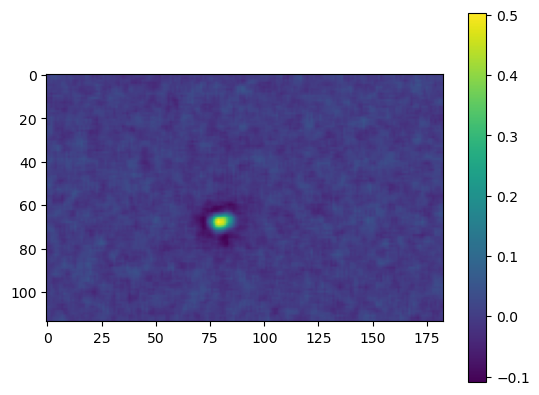

In [5]:
import matplotlib.pyplot as plt
plt.imshow(stas[102, -4, :, :, 0])
plt.colorbar()

## Load NAS STA for comparison

In [2]:
importlib.reload(ra.utils.vision_utils)
exp_name = '20260415C'
chunk_name = 'chunk1'
vcd = ra.utils.vision_utils.get_analysis_vcd(exp_name, chunk_name, 'kilosort2.5', include_sta=True)

Loading VCD from /mnt/Volumes/data-1/analysis/20260415C/chunk1/kilosort2.5 ...
VCD loaded with 492 cells.



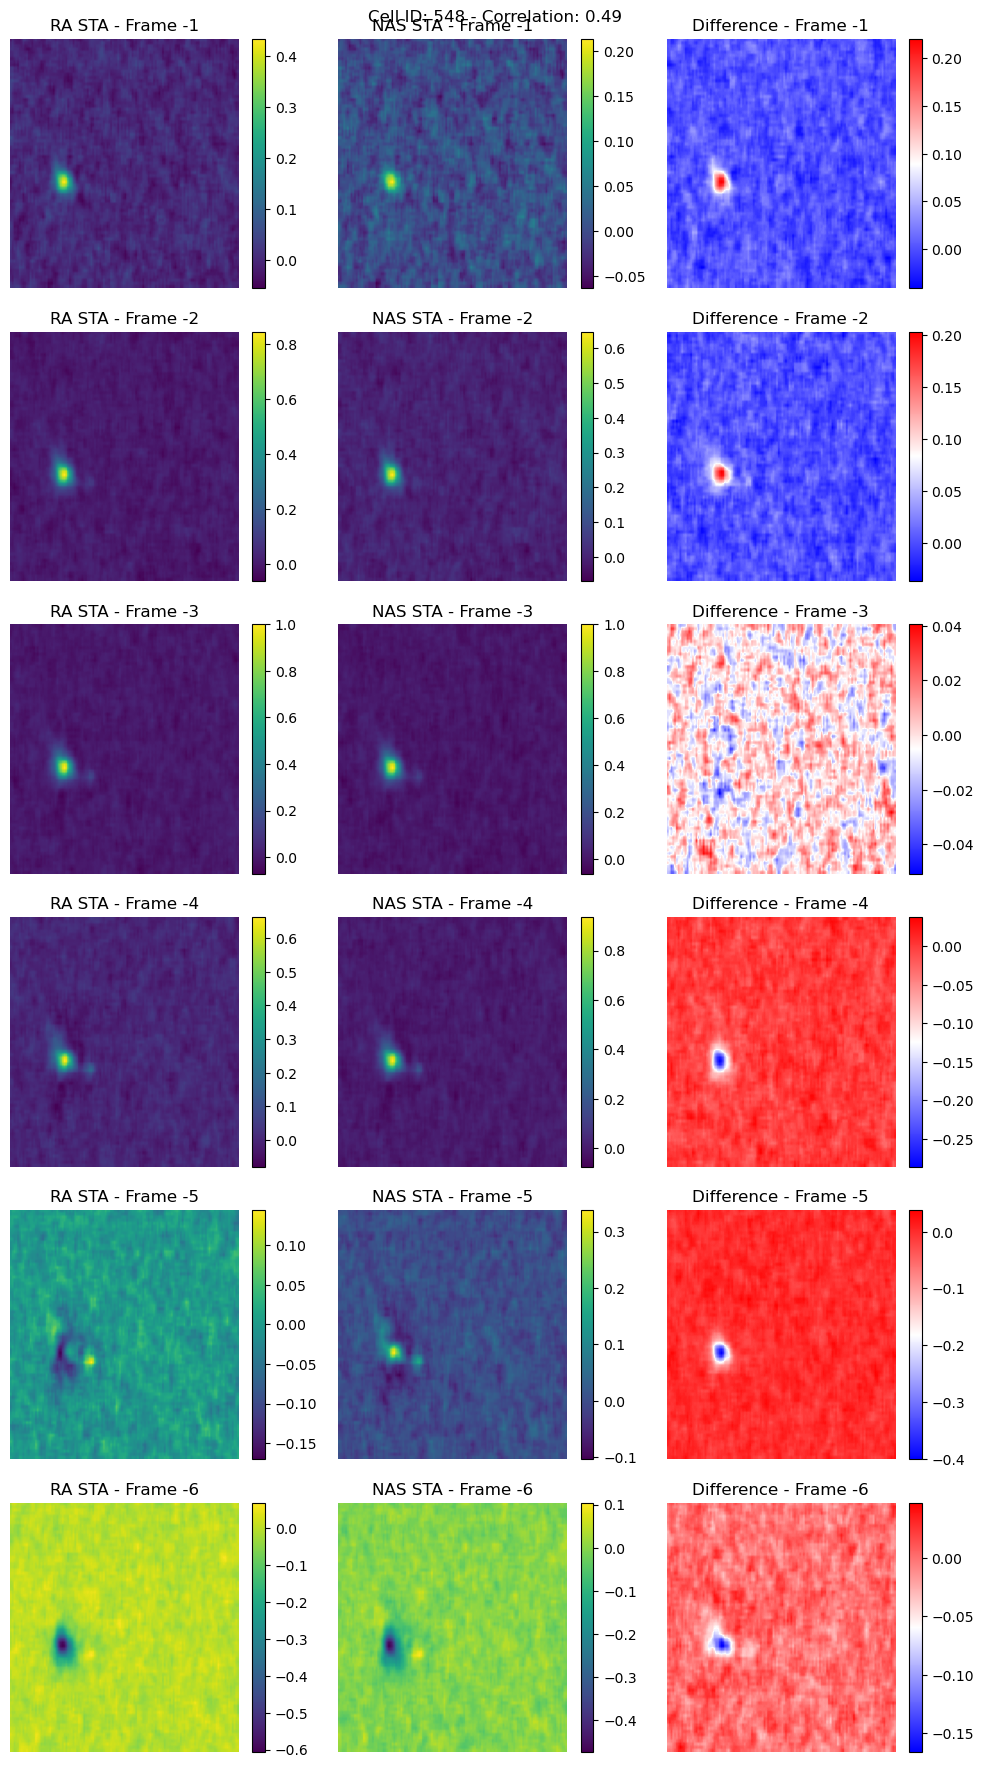

In [12]:
def compare_sta_to_vcd(stas, vcd, cell_idx=100):
    cell_ids = vcd.get_cell_ids()
    cell_id = cell_ids[cell_idx]

    ra_sta = stas[cell_idx]

    # [H, W, D] for each channel
    vcd_sta = vcd.get_sta_for_cell(cell_id)
    vcd_sta = [vcd_sta.red, vcd_sta.green, vcd_sta.blue]
    # Make [D, H, W, C]
    vcd_sta = np.stack(vcd_sta, axis=-1).transpose(2, 0, 1, 3)

    # vcd sta is cropped, so crop ra_sta
    crop_h = vcd_sta.shape[1]
    crop_w = vcd_sta.shape[2]
    h_start = (ra_sta.shape[1] - crop_h) // 2
    w_start = (ra_sta.shape[2] - crop_w) // 2
    ra_sta = ra_sta[:, h_start:h_start+crop_h, w_start:w_start+crop_w, :]

    # Frame to plot
    ls_frames = [-1, -2, -3, -4, -5, -6]
    fig, axs = plt.subplots(nrows=len(ls_frames), ncols=3, figsize=(10, 3*len(ls_frames)))
    for i, i_frame in enumerate(ls_frames):
        im=axs[i, 0].imshow(ra_sta[i_frame, :, :, 0], aspect='auto')
        plt.colorbar(im, ax=axs[i, 0])
        axs[i, 0].set_title(f'RA STA - Frame {i_frame}')
        im=axs[i, 1].imshow(vcd_sta[i_frame, :, :, 0], aspect='auto')
        plt.colorbar(im, ax=axs[i, 1])
        axs[i, 1].set_title(f'NAS STA - Frame {i_frame}')
        diff = ra_sta[i_frame, :, :, 0] - vcd_sta[i_frame, :, :, 0]
        im=axs[i, 2].imshow(diff, aspect='auto', cmap='bwr')
        plt.colorbar(im, ax=axs[i, 2])
        axs[i, 2].set_title(f'Difference - Frame {i_frame}')
        
    r = np.corrcoef(ra_sta.flatten(), vcd_sta.flatten())[0, 1]
    plt.suptitle(f'Cell ID: {cell_id} - Correlation: {r:.2f}')
    for ax in axs.flatten():
        ax.axis('off')
    plt.tight_layout()
    plt.show()

compare_sta_to_vcd(stas, vcd, cell_idx=450)